# Image and Video Processing - Lab 4: Segmentation

In this lab, you will learn about traditional segmentation in Python.

**In order to complete the Lab, you need to finish all required tasks in the lab session and have one of the teacher to check your result.**

### Load Libraries

In [26]:
import cv2
import numpy as np
import sys
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


## Region-based Segmentation
### Step 1: Flood Fill Algorithm
Implement a recursive flood fill algorithm. Use N_8 for neighbourhood.

In [27]:
sys.setrecursionlimit(10**6) 

def flood_fill_recursive_8(image, x, y, target_color, visited, current_blob):
    visited[x,y] = 1
    if image[x,y] == target_color:
        current_blob.append((x,y))
        for px, py in find_neighbours(image, x, y):
            if visited[px, py] == 0:
                flood_fill_recursive_8(image, px, py, target_color, visited, current_blob)
    else:
        return


def find_neighbours(image, x, y):
    n = [(1,0), (-1, 0), (0, 1), (0,-1), (1, 1), (-1, -1), (-1, 1), (1, -1)]
    neighbours = []
    for px, py in n:
        x_tmp, y_tmp = x+px, y+py
        if 0 <= x_tmp < image.shape[0] and 0 <= y_tmp < image.shape[1]:
            neighbours.append((x_tmp, y_tmp))
    return neighbours





### Step 2: Flood Fill Checker

In [28]:
def check_flood_fill():
    
    img = np.array([
        [255, 255, 0],
        [255, 255, 0],
        [0,   0,   255]
    ])
    visited = np.zeros((3,3), dtype=bool)
    pixels_found = []
    
    flood_fill_recursive_8(img, 0, 0, 255, visited, pixels_found)
    
    if len(pixels_found) == 5:
        print("Flood Fill Pixel Count is CORRECT!")
    else:
        print("Flood Fill Pixel Count is WRONG!")
        print("I found", len(pixels_found), "pixels, but it should be 5.")

check_flood_fill()


Flood Fill Pixel Count is CORRECT!


### Step 3: Find Blobs

Use the flood fill algorithm above to detect blobs.

In [29]:
def detect_blobs(binary_image):
    blobs = []
    visited = np.zeros((binary_image.shape[0], binary_image.shape[1]), dtype=bool)
    visited[binary_image==0] = 1
    while True:
        unvisited = np.argwhere(visited == 0)
        if len(unvisited)==0:
            break
        x,y = unvisited[0]
        new_blob = []
        flood_fill_recursive_8(binary_image, x, y, binary_image[x,y], visited, new_blob)
        blobs.append(new_blob)
    return blobs

### Step 4: Blob Checker

In [30]:
def check_blobs():
    
    img = np.array([
        [255, 255, 0, 0],
        [255, 255, 0, 0],
        [0,   0,   0, 255],
        [0,   0,   0, 255]
    ])

    found_blobs = detect_blobs(img)

    if len(found_blobs) == 2:
        print("Blob Count is CORRECT!")
    else:
        print("Blob Count is WRONG!")
        print("I found", len(found_blobs), "blobs, but it should be 2.")
    
    if len(found_blobs) == 2:
        size1 = len(found_blobs[0])
        size2 = len(found_blobs[1])
        print(f"Blob sizes found: {size1} and {size2} pixels.")

check_blobs()

Blob Count is CORRECT!
Blob sizes found: 4 and 2 pixels.


### Step 5: Visualize Blobs

Use get_cmap from plt library and "gist_rainbow" to get a set of high contrast distinct colors.

Color every blob with a diffent color. 

Create an image with the blobs colored.

Hint: get_cmap provides values between 0 and 1.

In [31]:
def visualize_blobs(original_binary, blobs_list):
    visualization_img = np.zeros((original_binary.shape[0], original_binary.shape[1], 3), dtype=np.uint8)
    cmap = plt.get_cmap('gist_rainbow')
    colors = []
    for i in range(len(blobs_list)):
        val = i / len(blobs_list)
        color = cmap(val)[:3]
        scaled_color = (np.array(color) * 255).astype(np.uint8)
        colors.append(scaled_color)
    for idx, blob in enumerate(blobs_list):
        for (x,y) in blob:
            visualization_img[x,y] = colors[idx]
    return visualization_img


### Step 6: Visualization Checker

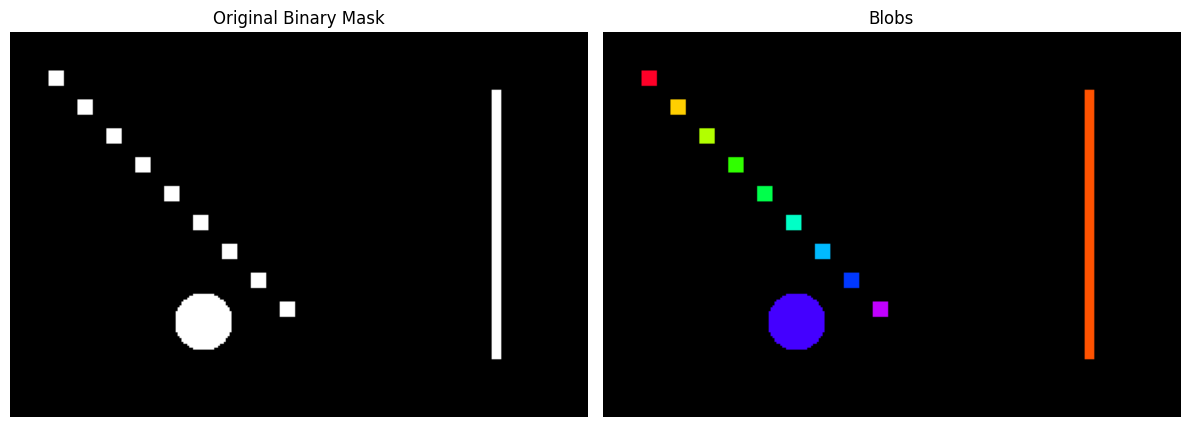

In [32]:
def define_image():
    width, height = 300, 200
    example_binary = np.zeros((height, width), dtype=np.uint8)

    # Blob 1: A diagonal dashed line
    for i in range(20, 150, 15):
        example_binary[i:i+8, i:i+8] = 255

    # Blob 2: A solid vertical line
    example_binary[30:170, 250:255] = 255

    # Blob 3: A small circular noise patch
    for r in range(height):
        for c in range(width):
            if (r-150)**2 + (c-100)**2 < 15**2:
                example_binary[r, c] = 255
    return example_binary

binary_img = define_image()

def check_visualization(binary_img):
    
    found_blobs_list = detect_blobs(binary_img)

    visualization = visualize_blobs(binary_img, found_blobs_list)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(binary_img, cmap='gray')
    plt.title('Original Binary Mask')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title('Blobs')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

check_visualization(binary_img)

## Cluster-based Segmentation
### Step 1: Load Color Image

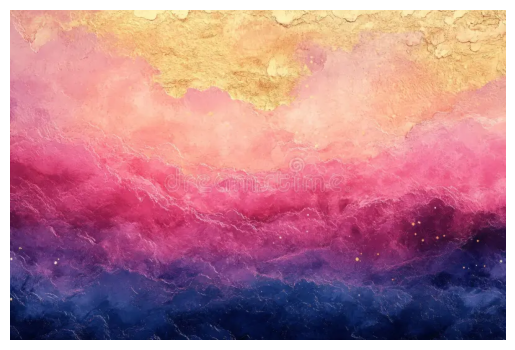

In [33]:
def load_color_image(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

img = load_color_image("test.jpeg")

# Check if the image loaded successfully
if img is None:
    raise FileNotFoundError("Image not found. Please check the file path.")

# Display the results
plt.imshow(img,cmap="gray")
plt.axis('off')
plt.show()

### Step 2: Cluster segmentation

Flatten the image to (height * width, 3 channels)

Run Kmeans

Change the value of each pixel in a cluster with the same color (the color of the centroid)

Generate the newly colored image

Return image

In [34]:
def cluster_segmentation(img, k=3):
    flattened_image = img.reshape(-1, 3)
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(flattened_image)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    segmented = centroids[labels]
    segmented_image = segmented.reshape(img.shape).astype(np.uint8)
    return segmented_image

### Cluster Segmentation Checker

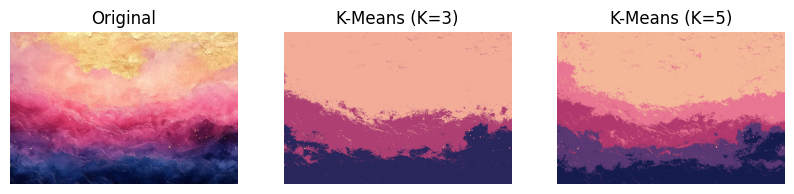

In [35]:
segmented3 = cluster_segmentation(img, k=3)
segmented5 = cluster_segmentation(img, k=5)

# visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Original");plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(segmented3); plt.title("K-Means (K=3)");plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(segmented5); plt.title("K-Means (K=5)");plt.axis('off')
plt.show()